# Pre-stimulus block decodability vs LDA 1 (trial-count matched + pseudosession control)
Per session x region: decode block (0.2 vs 0.8) from the pre-stimulus window, **downsampled to a common trial count** across sessions (removes the trial-count confound). A **pseudosession null** (block re-generated with the same run-length structure, decoded from the *real* activity) controls for slow drift/autocorrelation. Corrected decodability = real - pseudo-mean, correlated with LDA 1.

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, os
from collections import defaultdict
from iblatlas.regions import BrainRegions
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score
from scipy.stats import pearsonr, spearmanr
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid'); plt.rcParams['figure.facecolor'] = 'white' 

In [14]:
prefix = '/home/ines/repositories/representation_learning_variability/paper-individuality/'
firing_rates_dir = prefix + 'data/firing_rates/'
trials_path = prefix + '4_mice/all_trials_04-05-2026'
out_path = prefix + 'neural/decoding/decoding_block_pseudo_persession.parquet'
sweep_out_path = prefix + 'neural/decoding/decoding_block_pseudo_ncomp_sweep.parquet'

REGION_LEVEL = 'cosmos'
DROP = ['root', 'void']
PRESTIM_WIN = (-0.4, 0.0)
N_TARGET = 150            # common #(biased) trials per session
N_EVAL = 20              # PCA components (fixed a priori; sweep cell checks k-robustness)
N_PSEUDO = 100            # pseudosessions for the null (IBL generative, biased-only)
N_SUBSAMPLE_REPEATS = 10  # random trial subsamples averaged per region (stabilises against seed)
CV_FOLDS = 5
MIN_NEURONS = 10
MIN_SESSIONS_CORR = 15
SEED = 0
# IBL block generative params (biased blocks only; 0.5 opening is dropped from real data too)
BLK_MEAN = 60; BLK_MIN = 20; BLK_MAX = 100

trials_df = pd.read_parquet(trials_path)
# full block per session, chronological (still includes the 0.5 opening; dropped in the decode cell)
block_by_session = {s: g.sort_values('trial_id').set_index('trial_id')['block'] for s, g in trials_df.groupby('session')}
lda = pd.read_pickle(prefix + 'clustering/mouse_LDA_5_bins_cut19-06-2026').rename(columns={0: 'lda_1'})
br = BrainRegions()
print("params set (k=%d, N_PSEUDO=%d, %d subsample repeats)" % (N_EVAL, N_PSEUDO, N_SUBSAMPLE_REPEATS))

params set (k=20, N_PSEUDO=100, 10 subsample repeats)


## Decoding + pseudosession helpers

In [3]:
rng = np.random.default_rng(SEED)

def generate_pseudo_blocks(n_trials, rng):
    """IBL biased-block generative sequence, NO 0.5 opening (the neutral opening is excluded from
    the real data too). Alternating 0.2/0.8 blocks whose lengths ~ exponential(mean=60) truncated
    to [20,100]. Returns array in {0.2,0.8} of length n_trials."""
    out = []
    side = float(rng.choice([0.2, 0.8]))
    while len(out) < n_trials:
        x = rng.exponential(BLK_MEAN)
        while x < BLK_MIN or x > BLK_MAX:
            x = rng.exponential(BLK_MEAN)
        out += [side] * int(x)
        side = 0.8 if side == 0.2 else 0.2
    return np.array(out[:n_trials])

def make_folds(X, y_split, k, cv, seed):
    """Precompute scaler+PCA per CV fold once (folds fixed by y_split); reused across many label sets."""
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=seed)
    folds = []
    for tr, te in skf.split(X, y_split):
        sc = StandardScaler().fit(X[tr]); Xtr, Xte = sc.transform(X[tr]), sc.transform(X[te])
        nc = min(k, Xtr.shape[1], Xtr.shape[0] - 1)
        pca = PCA(n_components=nc, random_state=seed).fit(Xtr)
        folds.append((tr, te, pca.transform(Xtr), pca.transform(Xte)))
    return folds

def acc_labels(folds, y):
    """Balanced accuracy for a label vector using precomputed fold embeddings (only LDA refits)."""
    a = []
    for tr, te, Ztr, Zte in folds:
        if len(np.unique(y[tr])) < 2 or len(np.unique(y[te])) < 2: a.append(np.nan); continue
        a.append(balanced_accuracy_score(y[te], LDA().fit(Ztr, y[tr]).predict(Zte)))
    return np.nanmean(a)

## Load pre-stimulus activity

In [4]:
pkl_files = sorted([f for f in os.listdir(firing_rates_dir) if f.startswith('firing_rate_')])
with open(os.path.join(firing_rates_dir, pkl_files[0]), 'rb') as f:
    s0 = pickle.load(f)
tcols = sorted([c for c in s0.columns if c.startswith('t_')], key=lambda x: float(x.split('_')[1]))
tsec = np.array([float(c.split('_')[1]) for c in tcols])
pre_cols = [c for c, m in zip(tcols, (tsec >= PRESTIM_WIN[0]) & (tsec <= PRESTIM_WIN[1])) if m]

sess_pre = defaultdict(list)
for i, fn in enumerate(pkl_files):
    try:
        with open(os.path.join(firing_rates_dir, fn), 'rb') as f:
            d = pickle.load(f)
        d = d[~d['area'].isin(DROP)]
        if len(d) == 0: continue
        session = d['session'].iloc[0]
        d = d.copy(); d['nuid'] = d['pid'].astype(str) + '__' + d['neuron_id'].astype(str)
        d['pre'] = d[pre_cols].mean(axis=1)
        piv = d.pivot_table(index='trial_id', columns='nuid', values='pre')
        amap = d.groupby('nuid')['area'].first()
        if REGION_LEVEL == 'cosmos':
            cmap = dict(zip(amap.dropna().unique(), br.acronym2acronym(amap.dropna().unique(), mapping='Cosmos')))
            amap = amap.map(cmap)
        sess_pre[session].append((piv, amap))
        if (i + 1) % 100 == 0: print(f"  {i+1}/{len(pkl_files)} files...")
    except Exception as e:
        print(f"Error {fn}: {e}")
print(f"Sessions loaded: {len(sess_pre)}")

  100/380 files...


  200/380 files...


  300/380 files...


Sessions loaded: 244


## Decode real + pseudosessions (trial-count matched)

In [5]:
records = []
for si, session in enumerate(sess_pre):
    X = pd.concat([p for p, _ in sess_pre[session]], axis=1)
    areas = pd.concat([a for _, a in sess_pre[session]]); areas = areas[~areas.index.duplicated()]
    blk = block_by_session.get(session)
    if blk is None: continue
    full = blk.values
    biased_pos_all = np.where(np.isin(full, [0.2, 0.8]))[0]         # contiguous biased span (0.5 opening dropped)
    if len(biased_pos_all) == 0: continue
    fb = biased_pos_all[0]                                          # first biased position (opening length)
    tids_all = blk.index.values[biased_pos_all]
    keep = np.isin(tids_all, X.index.values)                       # biased trials with neural data
    biased_pos = biased_pos_all[keep]; biased_tids = tids_all[keep]
    if len(biased_tids) < N_TARGET: continue
    real_seq = pd.Series(full[biased_pos]).map({0.2: 0, 0.8: 1}).values.astype(int)
    offsets = biased_pos - fb                                       # position within the biased span
    n_biased_all = len(biased_pos_all)
    # IBL pseudosessions over the biased span only (no 0.5) -> labels are always 0/1
    pseudos = []
    for _ in range(N_PSEUDO):
        pf = generate_pseudo_blocks(n_biased_all, rng)
        lab = pd.Series(pf[offsets]).map({0.2: 0, 0.8: 1}).values
        assert not np.isnan(lab).any(), "pseudo produced a non-biased label"
        pseudos.append(lab.astype(int))
    for region in pd.unique(areas.values):
        if region is None or (isinstance(region, float) and np.isnan(region)): continue
        cols = areas.index[areas.values == region]
        if len(cols) < MIN_NEURONS: continue
        Xr = X.loc[biased_tids, cols].values
        pos = np.where(~np.isnan(Xr).any(axis=1))[0]
        if len(pos) < N_TARGET: continue
        real_reps, pseudo_all = [], []                             # average real / pool null over repeats
        for _ in range(N_SUBSAMPLE_REPEATS):
            sub = rng.choice(pos, N_TARGET, replace=False)
            Xsub, y_real = Xr[sub], real_seq[sub]
            if len(np.unique(y_real)) < 2 or min(np.bincount(y_real)) < CV_FOLDS: continue
            folds = make_folds(Xsub, y_real, N_EVAL, CV_FOLDS, SEED)
            real_reps.append(acc_labels(folds, y_real))
            pseudo_all.extend(acc_labels(folds, ps[sub]) for ps in pseudos)
        if not real_reps: continue
        real = float(np.mean(real_reps))
        pm, psd = float(np.nanmean(pseudo_all)), float(np.nanstd(pseudo_all))
        records.append(dict(session=session, region=region, n_neurons=len(cols), n_trials=N_TARGET,
                            n_components=N_EVAL, n_repeats=len(real_reps),
                            real=real, pseudo_mean=pm, pseudo_std=psd,
                            corrected=real - pm, zscore=(real - pm) / (psd + 1e-9)))
    if (si + 1) % 40 == 0: print(f"  {si+1}/{len(sess_pre)} sessions...")

dec = pd.DataFrame(records)
dec.to_parquet(out_path)
print(f"Saved {len(dec)} entries (k={N_EVAL}, {N_SUBSAMPLE_REPEATS} repeats x {N_PSEUDO} pseudo) | "
      f"real mean={dec['real'].mean():.3f} pseudo mean={dec['pseudo_mean'].mean():.3f} "
      f"corrected mean={dec['corrected'].mean():.3f}")

  40/244 sessions...


  80/244 sessions...


  120/244 sessions...


  160/244 sessions...


  200/244 sessions...


  240/244 sessions...


Saved 587 entries (k=20, 10 repeats x 100 pseudo) | real mean=0.609 pseudo mean=0.593 corrected mean=0.016


## Correlate corrected block decodability with LDA 1 (+ plots)

In [15]:
dec = pd.read_parquet(out_path)   # reload from disk -> this + plot cell reproduce everything in seconds
p = dec.merge(lda[['session', 'lda_1', 'mouse_name']], on='session').dropna(subset=['lda_1'])
well = p.groupby('region')['session'].nunique(); well = well[well >= MIN_SESSIONS_CORR].index.tolist()
p = p[p.region.isin(well)]
print(f"n={len(p)} session-region entries (k={dec['n_components'].iloc[0]}); well-sampled regions: {well}\n")
for metric in ['real', 'corrected', 'zscore']:
    print(f"---- {metric} vs LDA 1 ----")
    for reg, g in p.groupby('region'):
        r, pv = pearsonr(g['lda_1'], g[metric]); rho, pvv = spearmanr(g['lda_1'], g[metric])
        print(f"  {reg:10s} n={len(g):3d}: r={r:+.2f} p={pv:.3f} | rho={rho:+.2f} p={pvv:.3f}")
    try:
        mm = smf.mixedlm(f"{metric} ~ lda_1 + C(region) + n_neurons", p, groups=p['mouse_name'],
                         vc_formula={'session': '0 + C(session)'}).fit(reml=True); ml = 'mouse+session'
    except Exception:
        mm = smf.mixedlm(f"{metric} ~ lda_1 + C(region) + n_neurons", p, groups=p['session']).fit(reml=True); ml = 'session'
    b, se, pv = mm.params['lda_1'], mm.bse['lda_1'], mm.pvalues['lda_1']
    print(f"  POOLED {metric} ~ lda_1 + C(region) + n_neurons + (1|mouse) [{ml}]: coef={b:+.4f} z={b/se:+.2f} p={pv:.4f}\n")

n=587 session-region entries (k=20); well-sampled regions: ['CB', 'CNU', 'CTXsp', 'HB', 'HPF', 'HY', 'Isocortex', 'MB', 'OLF', 'TH']

---- real vs LDA 1 ----
  CB         n= 50: r=+0.14 p=0.344 | rho=+0.20 p=0.162
  CNU        n= 64: r=-0.03 p=0.792 | rho=-0.02 p=0.888
  CTXsp      n= 19: r=+0.30 p=0.214 | rho=+0.25 p=0.307
  HB         n= 64: r=+0.20 p=0.112 | rho=+0.16 p=0.208
  HPF        n= 78: r=-0.06 p=0.596 | rho=-0.16 p=0.163
  HY         n= 20: r=-0.16 p=0.501 | rho=-0.27 p=0.246
  Isocortex  n=114: r=+0.20 p=0.029 | rho=+0.21 p=0.025
  MB         n= 64: r=+0.36 p=0.003 | rho=+0.29 p=0.018
  OLF        n= 28: r=+0.28 p=0.145 | rho=+0.30 p=0.119
  TH         n= 86: r=+0.15 p=0.173 | rho=+0.18 p=0.092
  POOLED real ~ lda_1 + C(region) + n_neurons + (1|mouse) [mouse+session]: coef=+0.0026 z=+2.98 p=0.0029

---- corrected vs LDA 1 ----
  CB         n= 50: r=+0.23 p=0.109 | rho=+0.19 p=0.175
  CNU        n= 64: r=+0.04 p=0.774 | rho=-0.01 p=0.956
  CTXsp      n= 19: r=+0.47 p=0.044

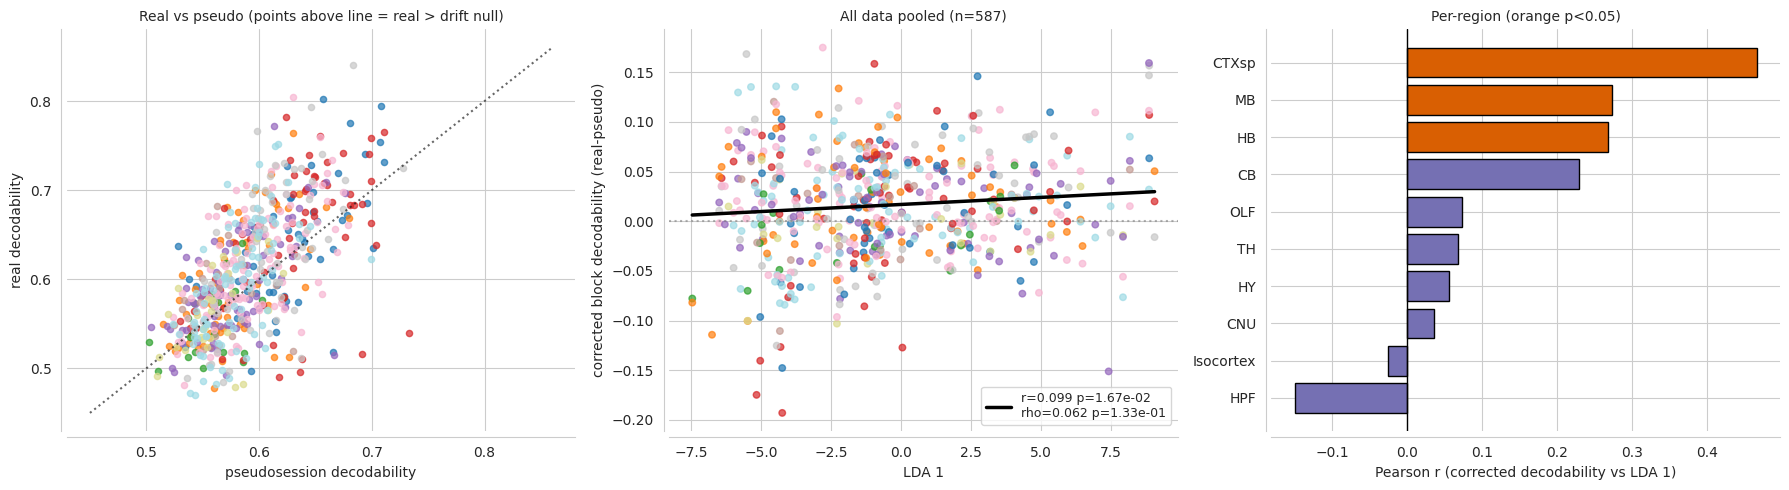

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
region_list = sorted(p['region'].unique())
pal = dict(zip(region_list, plt.cm.tab20(np.linspace(0, 1, len(region_list)))))
# (1) real vs pseudo levels
for reg in region_list:
    g = p[p.region == reg]; axes[0].scatter(g['pseudo_mean'], g['real'], color=pal[reg], s=20, alpha=0.7)
lims = [0.45, max(p['real'].max(), p['pseudo_mean'].max()) + 0.02]
axes[0].plot(lims, lims, 'k:', alpha=0.6); axes[0].set_xlabel('pseudosession decodability'); axes[0].set_ylabel('real decodability')
axes[0].set_title('Real vs pseudo (points above line = real > drift null)', fontsize=10); sns.despine(ax=axes[0], offset=5)
# (2) corrected vs LDA1, all data pooled
x = p['lda_1'].values; y = p['corrected'].values
r, pv = pearsonr(x, y); rho, pvv = spearmanr(x, y)
axes[1].scatter(x, y, c=[pal[rr] for rr in p['region']], s=22, alpha=0.7)
z = np.polyfit(x, y, 1); xl = np.linspace(x.min(), x.max(), 100)
axes[1].plot(xl, np.polyval(z, xl), 'k-', lw=2.5, label=f'r={r:.3f} p={pv:.2e}\nrho={rho:.3f} p={pvv:.2e}')
axes[1].axhline(0, color='gray', ls=':', alpha=0.6)
axes[1].set_xlabel('LDA 1'); axes[1].set_ylabel('corrected block decodability (real-pseudo)')
axes[1].set_title(f'All data pooled (n={len(p)})', fontsize=10); axes[1].legend(fontsize=9)
# (3) per-region r bar
rs = sorted([(reg, pearsonr(g['lda_1'], g['corrected'])[0], pearsonr(g['lda_1'], g['corrected'])[1])
             for reg, g in p.groupby('region')], key=lambda t: t[1])
cols = ['#d95f02' if pp < 0.05 else '#7570b3' for _, _, pp in rs]
axes[2].barh([t[0] for t in rs], [t[1] for t in rs], color=cols, edgecolor='black'); axes[2].axvline(0, color='black', lw=1)
axes[2].set_xlabel('Pearson r (corrected decodability vs LDA 1)'); axes[2].set_title('Per-region (orange p<0.05)', fontsize=10)
for ax in axes: sns.despine(ax=ax, offset=4)
plt.tight_layout(); plt.show()

## Per-session summary (averaged across regions) vs LDA 1
Loads the decode parquet, averages `real`/`corrected` decodability across regions within each session,
and plots vs LDA 1 with points colored by LDA 1 (one point per session). Just loads — no recompute.

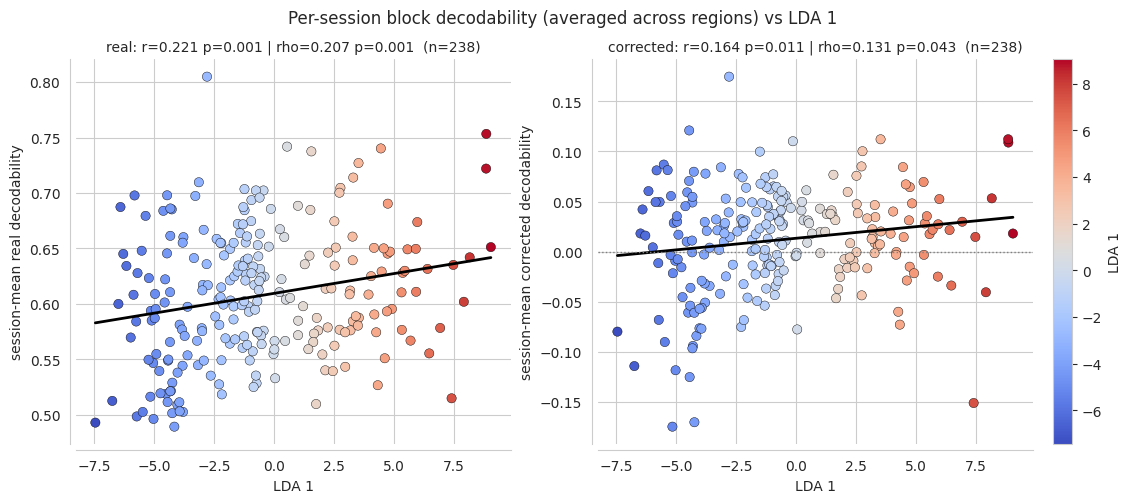

In [18]:
dsum = pd.read_parquet(out_path).merge(lda[['session', 'lda_1']], on='session').dropna(subset=['lda_1'])
persess = dsum.groupby('session').agg(real=('real', 'mean'), corrected=('corrected', 'mean'),
                                      lda_1=('lda_1', 'first'), n_regions=('region', 'nunique')).reset_index()
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, metric in zip(axes, ['real', 'corrected']):
    x, y = persess['lda_1'].values, persess[metric].values
    r, pv = pearsonr(x, y); rho, pvv = spearmanr(x, y)
    sc = ax.scatter(x, y, c=x, cmap='coolwarm', s=45, edgecolor='k', linewidth=0.3)
    z = np.polyfit(x, y, 1); xl = np.linspace(x.min(), x.max(), 100)
    ax.plot(xl, np.polyval(z, xl), 'k-', lw=2)
    if metric == 'corrected': ax.axhline(0, color='gray', ls=':', lw=1)
    ax.set_xlabel('LDA 1'); ax.set_ylabel(f'session-mean {metric} decodability')
    ax.set_title(f'{metric}: r={r:.3f} p={pv:.3f} | rho={rho:.3f} p={pvv:.3f}  (n={len(persess)})', fontsize=10)
    sns.despine(ax=ax, offset=4)
cbar = fig.colorbar(sc, ax=axes, fraction=0.03, pad=0.02); cbar.set_label('LDA 1')
fig.suptitle('Per-session block decodability (averaged across regions) vs LDA 1', fontsize=12)
plt.show()

## Robustness: does the LDA 1 correlation depend on the number of PCA components?
Lighter diagnostic (fewer repeats / pseudosessions) sweeping k. PCA components are nested, so we fit
PCA once per fold at `K_MAX` and slice the first k columns. We report the pooled mixed-model p at each
k so k=20 is seen in context (not cherry-picked). Absent at k<=3, appears at k=5, most stable at k>=15.

In [12]:
K_MAX = 30; KS = [1, 2, 3, 5, 8, 10, 15, 20, 30]; SW_REPEATS = 3; SW_PSEUDO = 50
rng_sw = np.random.default_rng(SEED)

def folds_kmax(X, y_split):
    skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED); out = []
    for tr, te in skf.split(X, y_split):
        sc = StandardScaler().fit(X[tr]); Xtr, Xte = sc.transform(X[tr]), sc.transform(X[te])
        nc = min(K_MAX, Xtr.shape[1], Xtr.shape[0] - 1)
        pca = PCA(n_components=nc, random_state=SEED).fit(Xtr)
        out.append((tr, te, pca.transform(Xtr), pca.transform(Xte)))
    return out

def acc_k(folds, y, k):
    a = []
    for tr, te, Ztr, Zte in folds:
        kk = min(k, Ztr.shape[1])
        if len(np.unique(y[tr])) < 2 or len(np.unique(y[te])) < 2: a.append(np.nan); continue
        a.append(balanced_accuracy_score(y[te], LDA().fit(Ztr[:, :kk], y[tr]).predict(Zte[:, :kk])))
    return np.nanmean(a)

sw = []
for session in sess_pre:
    X = pd.concat([p for p, _ in sess_pre[session]], axis=1)
    areas = pd.concat([a for _, a in sess_pre[session]]); areas = areas[~areas.index.duplicated()]
    blk = block_by_session.get(session)
    if blk is None: continue
    full = blk.values; bpa = np.where(np.isin(full, [0.2, 0.8]))[0]
    if len(bpa) == 0: continue
    fb = bpa[0]; tids_all = blk.index.values[bpa]; keep = np.isin(tids_all, X.index.values)
    biased_pos = bpa[keep]; biased_tids = tids_all[keep]
    if len(biased_tids) < N_TARGET: continue
    real_seq = pd.Series(full[biased_pos]).map({0.2: 0, 0.8: 1}).values.astype(int)
    offsets = biased_pos - fb; n_bias = len(bpa)
    pseudos = []
    for _ in range(SW_PSEUDO):
        pf = generate_pseudo_blocks(n_bias, rng_sw)
        pseudos.append(pd.Series(pf[offsets]).map({0.2: 0, 0.8: 1}).values.astype(int))
    for region in pd.unique(areas.values):
        if region is None or (isinstance(region, float) and np.isnan(region)): continue
        cols = areas.index[areas.values == region]
        if len(cols) < MIN_NEURONS: continue
        Xr = X.loc[biased_tids, cols].values; pos = np.where(~np.isnan(Xr).any(axis=1))[0]
        if len(pos) < N_TARGET: continue
        acc = {k: {'r': [], 'c': []} for k in KS}
        for _ in range(SW_REPEATS):
            sub = rng_sw.choice(pos, N_TARGET, replace=False); Xsub, y_real = Xr[sub], real_seq[sub]
            if len(np.unique(y_real)) < 2 or min(np.bincount(y_real)) < CV_FOLDS: continue
            folds = folds_kmax(Xsub, y_real)
            for k in KS:
                rk = acc_k(folds, y_real, k); pm = np.nanmean([acc_k(folds, ps[sub], k) for ps in pseudos])
                acc[k]['r'].append(rk); acc[k]['c'].append(rk - pm)
        if not acc[KS[0]]['r']: continue
        rec = dict(session=session, region=region, n_neurons=len(cols))
        for k in KS:
            rec[f'real_{k}'] = np.mean(acc[k]['r']); rec[f'corr_{k}'] = np.mean(acc[k]['c'])
        sw.append(rec)

sw_raw = pd.DataFrame(sw)
sw_raw.to_parquet(sweep_out_path)                 # saved -> re-run the table below from disk without redoing the sweep
sw = sw_raw.merge(lda[['session', 'lda_1', 'mouse_name']], on='session').dropna(subset=['lda_1'])
sw = sw[sw.region.isin(well)]
print(f"sweep saved: {len(sw_raw)} entries ({SW_REPEATS} repeats x {SW_PSEUDO} pseudo) -> {sweep_out_path}")
print(f"used in table: n={len(sw)}\n")
print(f"{'k':>4} | {'real p':>8} {'real z':>7} | {'corr p':>8} {'corr z':>7} | {'mean real':>9} {'mean corr':>9}")
for k in KS:
    line = f"{k:>4} |"
    for m in [f'real_{k}', f'corr_{k}']:
        try:
            mm = smf.mixedlm(f"{m} ~ lda_1 + C(region) + n_neurons", sw, groups=sw['mouse_name'],
                             vc_formula={'session': '0 + C(session)'}).fit(reml=True)
        except Exception:
            mm = smf.mixedlm(f"{m} ~ lda_1 + C(region) + n_neurons", sw, groups=sw['session']).fit(reml=True)
        b, se, pv = mm.params['lda_1'], mm.bse['lda_1'], mm.pvalues['lda_1']
        line += f" {pv:>8.4f} {b/se:>7.2f} |"
    line += f" {sw[f'real_{k}'].mean():>9.3f} {sw[f'corr_{k}'].mean():>9.3f}"
    print(line + ("   <- locked k" if k == N_EVAL else ""))

KeyboardInterrupt: 

## Sweep plots (load from parquet — no recompute)
Reads `sweep_out_path` and plots decodability-vs-k and pooled LDA-1 p-vs-k. **Run this instead of the
heavy sweep cell above** — it just loads the saved results. (Only the mixed-model p per k is refit; seconds.)

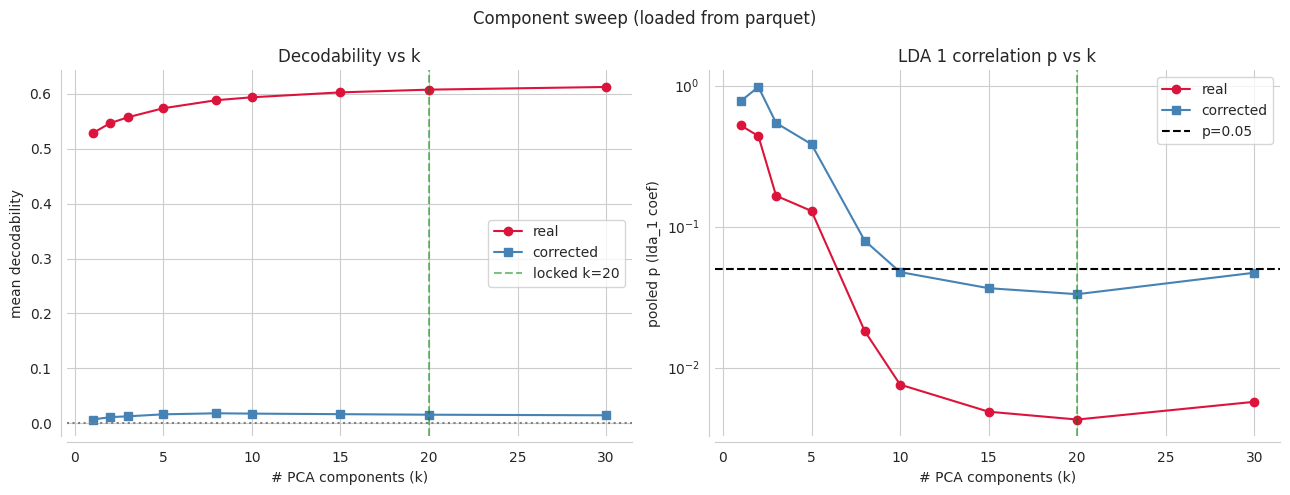

In [19]:
sw_load = pd.read_parquet(sweep_out_path).merge(lda[['session', 'lda_1', 'mouse_name']], on='session').dropna(subset=['lda_1'])
wk = sw_load.groupby('region')['session'].nunique(); sw_load = sw_load[sw_load.region.isin(wk[wk >= MIN_SESSIONS_CORR].index)]
KS = [1, 2, 3, 5, 8, 10, 15, 20, 30]; rows = []
for k in KS:
    d = {'k': k, 'mean_real': sw_load[f'real_{k}'].mean(), 'mean_corr': sw_load[f'corr_{k}'].mean()}
    for m in ['real', 'corr']:
        try:
            mm = smf.mixedlm(f'{m}_{k} ~ lda_1 + C(region) + n_neurons', sw_load, groups=sw_load['mouse_name'],
                             vc_formula={'session': '0 + C(session)'}).fit(reml=True)
        except Exception:
            mm = smf.mixedlm(f'{m}_{k} ~ lda_1 + C(region) + n_neurons', sw_load, groups=sw_load['session']).fit(reml=True)
        d[f'{m}_p'] = mm.pvalues['lda_1']
    rows.append(d)
swp = pd.DataFrame(rows)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(swp.k, swp.mean_real, 'o-', color='crimson', label='real')
axes[0].plot(swp.k, swp.mean_corr, 's-', color='steelblue', label='corrected')
axes[0].axhline(0, color='gray', ls=':'); axes[0].axvline(N_EVAL, color='green', ls='--', alpha=0.5, label=f'locked k={N_EVAL}')
axes[0].set_xlabel('# PCA components (k)'); axes[0].set_ylabel('mean decodability'); axes[0].legend(); axes[0].set_title('Decodability vs k')
axes[1].plot(swp.k, swp.real_p, 'o-', color='crimson', label='real')
axes[1].plot(swp.k, swp.corr_p, 's-', color='steelblue', label='corrected')
axes[1].axhline(0.05, color='k', ls='--', label='p=0.05'); axes[1].axvline(N_EVAL, color='green', ls='--', alpha=0.5)
axes[1].set_yscale('log'); axes[1].set_xlabel('# PCA components (k)'); axes[1].set_ylabel('pooled p (lda_1 coef)')
axes[1].legend(); axes[1].set_title('LDA 1 correlation p vs k')
for ax in axes: sns.despine(ax=ax, offset=4)
fig.suptitle('Component sweep (loaded from parquet)', fontsize=12); plt.tight_layout(); plt.show()

## Permutation + Bayes factor (same test as FF / FR / noise-correlations) + mouse-clustering check
Applies `age_effect_test` (session-stratified permutation of `lda_1` + partial-correlation JZS Bayes
factor) so block decodability is assessed on the **same footing** as the other neural metrics. Loads
the decode parquet only — no re-decoding.

**Result:** the *raw* decodability↔LDA-1 link is strong (BF10≈16), but the **drift-corrected** link is
**inconclusive** under the Bayes factor (BF10≈0.5) and non-significant once clustered by **mouse**.
`lda_1` is ~94% a per-mouse trait, so the 238 sessions carry only ~56 independent `lda_1` values — the
pooled session-grouped `mixedlm` above (p≈0.03) is anti-conservative. Every mouse-aware test
(per-mouse aggregation, mouse random intercept, cluster-robust SE, mouse-stratified permutation)
agrees the corrected effect is not established.

In [ ]:
# Permutation + partial-correlation Bayes factor, mirroring ff_psth_ldabin / fr_psth_ldabin /
# noise_corr_psth_lda's `age_effect_test` (lda_1 in place of age_years), so block decoding is
# assessed on the SAME footing as the other neural metrics. Loads the decode parquet only (no
# re-decoding). Unit = session x region, exactly the noise-correlation template (region_col='region',
# n_neurons covariate). Test statistic = FWL-residualized slope of lda_1; BF10 = partial-correlation
# JZS Bayes factor (Wetzels & Wagenmakers) via pingouin; p_perm shuffles lda_1 across the stratum.
#
# CRITICAL: lda_1 is ~94% a per-MOUSE trait (between-mouse SD ~3.7 vs within-mouse ~0.9, ~4
# sessions/mouse), so session / session x region rows are pseudoreplicates. Every mouse-aware test
# (mouse-stratified permutation, per-mouse aggregation, mouse random intercept, cluster-robust SE)
# agrees the *corrected* (drift-removed) effect is NON-significant; only session-level models -- incl.
# the pooled mixedlm in the correlate cell above, whose `0 + C(session)` vc collapses it to session
# clustering -- report p~0.03. The raw (uncorrected) effect is real but is largely slow drift.
import pingouin as pg
import statsmodels.api as sm
from scipy.stats import pearsonr

N_PERM_BF = 2000
pbf = pd.read_parquet(out_path).merge(lda[['session', 'lda_1', 'mouse_name']], on='session').dropna(subset=['lda_1'])
_well = pbf.groupby('region')['session'].nunique(); pbf = pbf[pbf.region.isin(_well[_well >= MIN_SESSIONS_CORR].index)]

def _design(df, extra_covars, use_region):
    cols = [pd.Series(1.0, index=df.index, name='Intercept')]
    if use_region: cols.append(pd.get_dummies(df['region'], drop_first=True).astype(float))
    cols.append(df[list(extra_covars)].astype(float))
    return pd.concat(cols, axis=1).values.astype(float)

def perm_bf_test(df, y_col, predictor='lda_1', extra_covars=('n_neurons',), use_region=True,
                 strat='mouse_name', n_perm=N_PERM_BF, seed=0):
    d = df.dropna(subset=[y_col, predictor, strat] + list(extra_covars)).reset_index(drop=True)
    y = d[y_col].values.astype(float); x = d[predictor].values.astype(float)
    Z = _design(d, extra_covars, use_region); Zpinv = np.linalg.pinv(Z)
    yr = y - Z @ (Zpinv @ y); xr = x - Z @ (Zpinv @ x)
    slope = np.sum(xr * yr) / np.sum(xr ** 2)
    r_partial, _ = pearsonr(xr, yr)
    bf10 = pg.bayesfactor_pearson(r_partial, max(len(d) - (Z.shape[1] - 1), 3))
    key = d.groupby(strat)[predictor].first(); idx = d[strat].values
    rng = np.random.default_rng(seed); perm = np.empty(n_perm)
    for i in range(n_perm):
        xp = pd.Series(rng.permutation(key.values), index=key.index).reindex(idx).values.astype(float)
        xpr = xp - Z @ (Zpinv @ xp); perm[i] = np.sum(xpr * yr) / np.sum(xpr ** 2)
    return dict(y=y_col, n=len(d), n_strat=key.size, slope=slope, r_partial=r_partial,
                bf10=bf10, p_perm=float(np.mean(np.abs(perm) >= np.abs(slope))))

def _bf_label(bf):
    return ('strong H1' if bf > 10 else 'moderate H1' if bf > 3 else 'strong H0' if bf < 1/10
            else 'moderate H0' if bf < 1/3 else 'inconclusive')

def _print(rows, title):
    print('\n' + title)
    print(f"{'metric':<11}{'n':>6}{'n_strat':>8}{'slope':>10}{'r_part':>8}{'BF10':>9}{'evidence':>15}{'p_perm':>9}")
    for r in rows:
        print(f"{r['y']:<11}{r['n']:>6}{r['n_strat']:>8}{r['slope']:>10.4f}{r['r_partial']:>8.3f}"
              f"{r['bf10']:>9.3g}{_bf_label(r['bf10']):>15}{r['p_perm']:>9.4f}")

# Primary: session x region, MOUSE-stratified permutation (mouse-aware -> the honest default).
_print([perm_bf_test(pbf, m, strat='mouse_name') for m in ['real', 'corrected', 'zscore']],
       "session x region | y ~ lda_1 + C(region) + n_neurons | MOUSE-stratified permutation")
# Session-stratified (what ff/fr/noise-corr use) shown for comparison -> NOT mouse-aware here.
_print([perm_bf_test(pbf, m, strat='session') for m in ['real', 'corrected', 'zscore']],
       "session x region | same model | SESSION-stratified permutation (comparison; anti-conservative for lda_1)")

# Mouse-aware robustness panel for the corrected effect: all should agree (non-significant).
print("\nMouse-aware robustness | corrected block decodability vs lda_1:")
pm = pbf.groupby('mouse_name').agg(corrected=('corrected', 'mean'), lda_1=('lda_1', 'first'),
                                   n_neurons=('n_neurons', 'mean')).reset_index()
r_pm, p_pm = pearsonr(pm['lda_1'], pm['corrected'])
print(f"  per-mouse aggregation (n_mice={len(pm)}): pearson r={r_pm:+.3f} p={p_pm:.4f}")
_Xc = sm.add_constant(pd.concat([pbf[['lda_1', 'n_neurons']],
                                 pd.get_dummies(pbf['region'], drop_first=True).astype(float)], axis=1))
_ols = sm.OLS(pbf['corrected'], _Xc).fit(cov_type='cluster', cov_kwds={'groups': pbf['mouse_name']})
print(f"  OLS + cluster-robust SE by mouse:        coef={_ols.params['lda_1']:+.4f} p={_ols.pvalues['lda_1']:.4f}")
_mm = smf.mixedlm("corrected ~ lda_1 + C(region) + n_neurons", pbf, groups=pbf['mouse_name']).fit(reml=True)
print(f"  mixedlm mouse random intercept:          coef={_mm.params['lda_1']:+.4f} p={_mm.pvalues['lda_1']:.4f}")
print("  (contrast: session-grouped mixedlm in the correlate cell gives p~0.03 -- session-level "
      "pseudoreplication, since lda_1 is a per-mouse trait)")